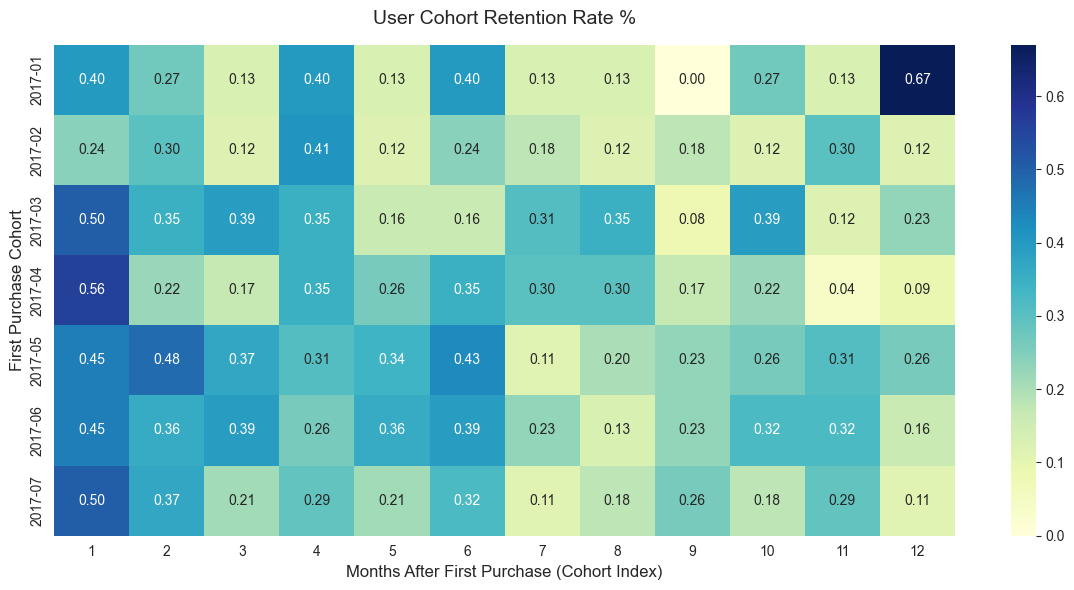

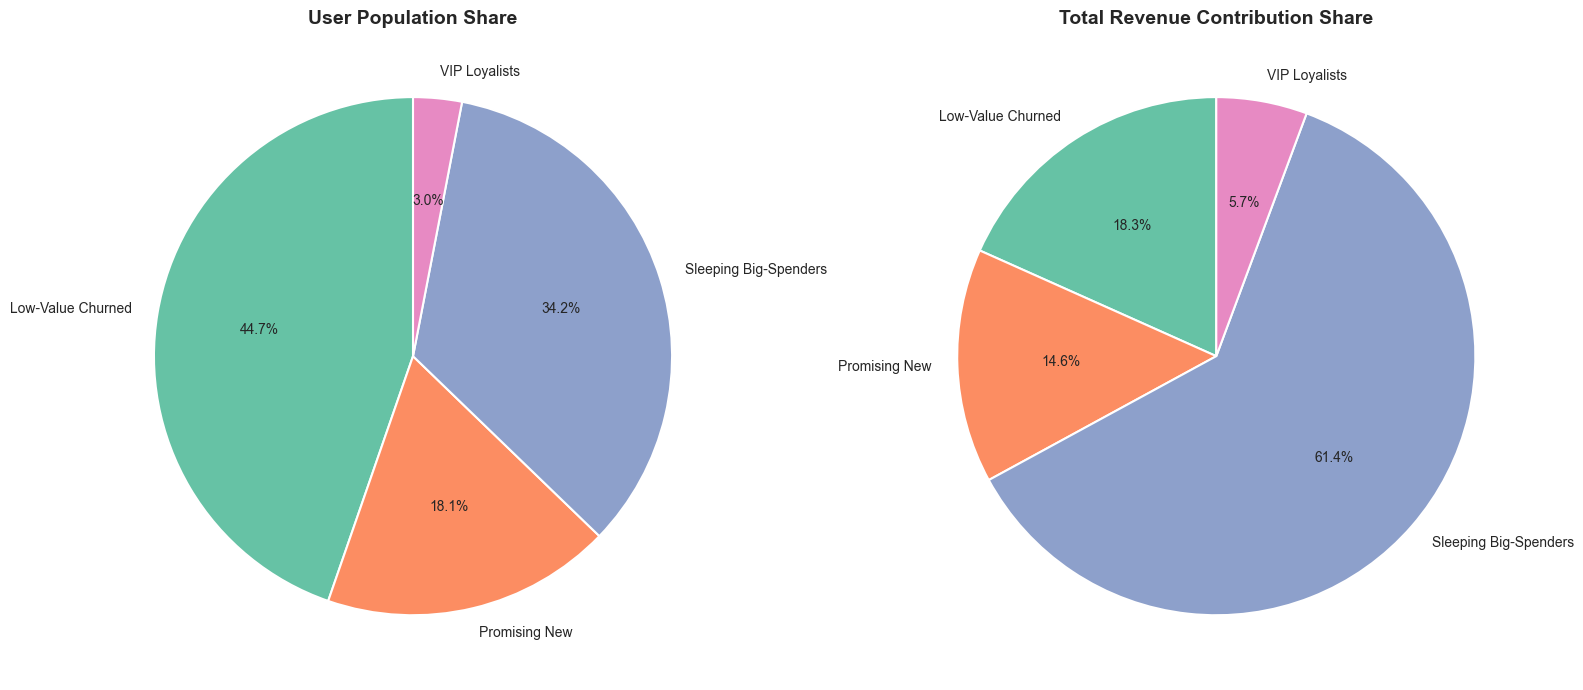

In [1]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
import sys
import warnings

# 忽略绘图和运行时的系统警告
warnings.filterwarnings('ignore')
sys.path.append('../')

# 导入业务与可视化模块
from src.funnel import FunnelAnalyzer
from src.rfm import RFMAnalyzer
from src.visualizer import Visualizer
from src.analyzer import OlistBIEngine

# ==========================================
# 1. 数据加载与主表 (ABT) 构建
# ==========================================
df_orders_clean = pd.read_parquet("../data/processed/olist_orders_clean.parquet")
df_payments_clean = pd.read_parquet("../data/processed/olist_payments_clean.parquet")
df_customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
df_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
df_products = pd.read_csv("../data/raw/olist_products_dataset.csv")

# 复用基础引擎提取合并后的大表
engine = OlistBIEngine(df_orders_clean, df_payments_clean, df_customers, df_items, df_products)
df_master = engine.build_analytical_base_table()

# ==========================================
# 2. 实例化解耦后的分析模块并计算指标
# ==========================================
funnel_module = FunnelAnalyzer(df_master)
rfm_module = RFMAnalyzer(df_master)

# 执行指标计算
cohort_matrix = funnel_module.calculate_cohort_matrix()
df_rfm = rfm_module.generate_rfm_segments()

# ==========================================
# 3. 构建 Jupyter 交互式看板 UI
# ==========================================
# 定义输出组件
output_cohort = widgets.Output()
output_rfm = widgets.Output()

# 渲染留存分析视图
with output_cohort:
    fig_cohort = Visualizer.plot_cohort_heatmap(cohort_matrix)
    display(fig_cohort)

# 渲染 RFM 用户价值分类视图
with output_rfm:
    fig_rfm = Visualizer.plot_rfm_revenue_share(df_rfm)
    display(fig_rfm)

# 组装标签页 (Tab) 布局
dashboard_tab = widgets.Tab(children=[output_cohort, output_rfm])
dashboard_tab.set_title(0, 'User Cohort Retention (用户留存)')
dashboard_tab.set_title(1, 'RFM Segmentation (价值分群)')

# 渲染最终看板
display(dashboard_tab)